In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import timeit

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

In [15]:
column_names = [
    'target_class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color',
    'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat'
]
df = pd.read_csv('agaricus-lepiota.data', header=None, names=column_names)
print(" ---------- STRUKTURA KOLUMN ---------- ")
print(df.dtypes)
print("-" * 30)

print("\n ----------  INFO ----------  ")
df.info()

print("\n ----------  STATYSTYKI OPISOWE ----------  ")
print(df.describe())

print("\n ----------  PIERWSZE WIERSZE ----------  ")
print(df.head())

print("----- MISSING DATA -----")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.any() else "Wszystko jest")
print()

#Duplitakty
print("----- DUPLICATES -----")
duplicates_count = df.duplicated().sum()
print(f"Liczba zduplikowanych wierszy: {duplicates_count}")
print()

print("\n---------- ROZKŁAD KLAS (jadalne vs trujące) ----------")
print(df['target_class'].value_counts())

 ---------- STRUKTURA KOLUMN ---------- 
target_class                str
cap-shape                   str
cap-surface                 str
cap-color                   str
bruises                     str
odor                        str
gill-attachment             str
gill-spacing                str
gill-size                   str
gill-color                  str
stalk-shape                 str
stalk-root                  str
stalk-surface-above-ring    str
stalk-surface-below-ring    str
stalk-color-above-ring      str
stalk-color-below-ring      str
veil-type                   str
veil-color                  str
ring-number                 str
ring-type                   str
spore-print-color           str
population                  str
habitat                     str
dtype: object
------------------------------

 ----------  INFO ----------  
<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dty

In [16]:
df['target_class'] = df['target_class'].map({'e': 0, 'p': 1})

X = df.drop('target_class', axis=1)
y = df['target_class']

X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded = X_encoded.astype(int)
#print(X_encoded.head())

In [ ]:
NIE ODPALAC PONOWNIE BO ZAMIENIA LICZBY NA NAN

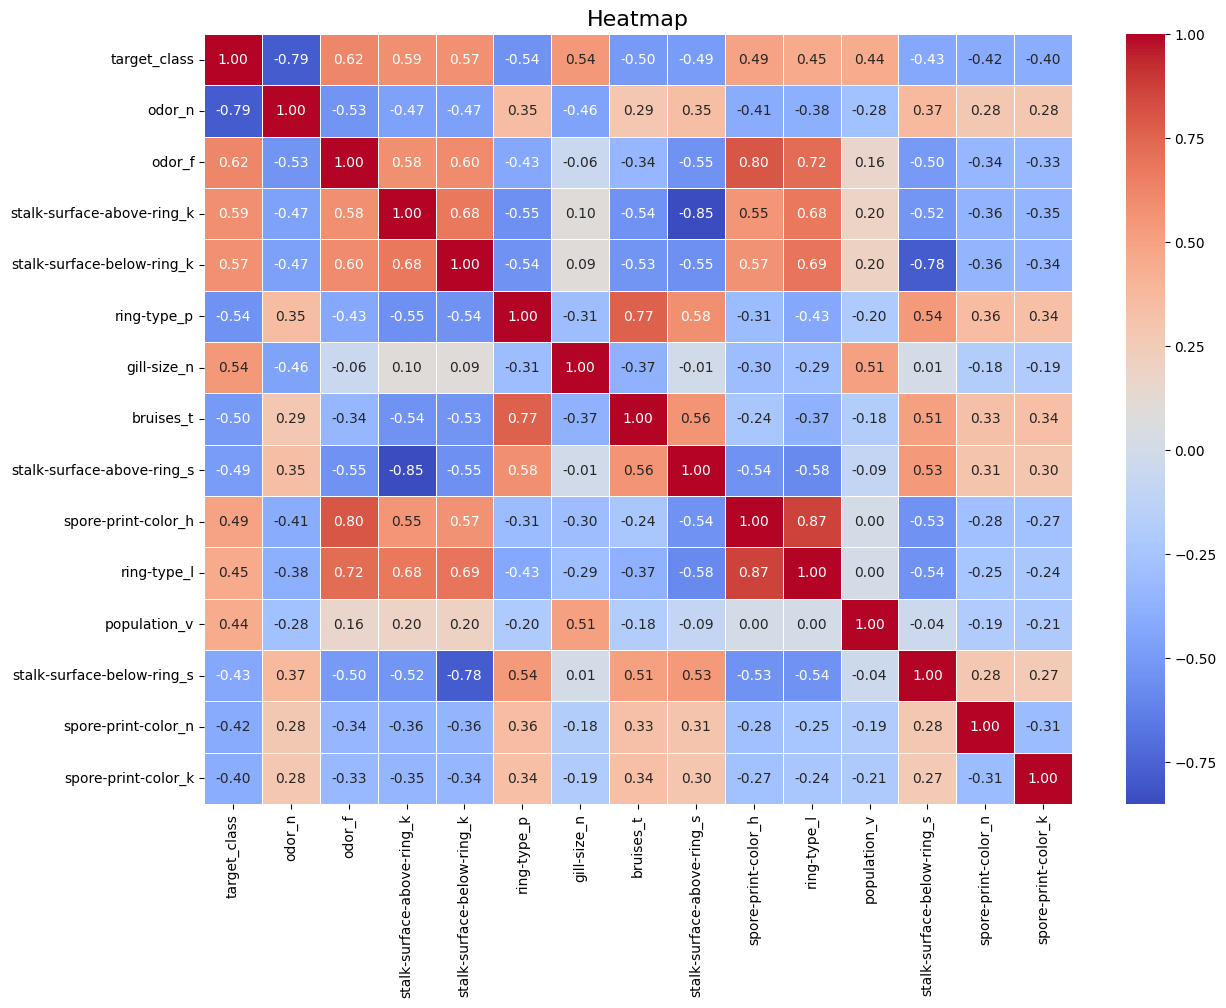

In [17]:
dane_do_korelacji = pd.concat([X_encoded, y], axis=1)
pelna_korelacja = dane_do_korelacji.corr()
najwazniejsze_kolumny = pelna_korelacja.abs().nlargest(15, 'target_class').index

plt.figure(figsize=(14, 10))

sns.heatmap(
    dane_do_korelacji[najwazniejsze_kolumny].corr(), 
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Heatmap', fontsize=16)
plt.show()

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)
#kretynski zbior
print(f"Rozmiar zbioru treningowego: {X_train.shape[0]} probek")
print(f"Rozmiar zbioru testowego: {X_test.shape[0]} probek")

Rozmiar zbioru treningowego: 6499 probek
Rozmiar zbioru testowego: 1625 probek


In [24]:
dt_model = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)

total_time = timeit.timeit(lambda: dt_model.predict(X_test), number=10)
inference_time_avg = total_time / 10

y_pred_dt = dt_model.predict(X_test)

print("Raport dla drzewa\n")
print(classification_report(y_test, y_pred_dt))

propability = dt_model.predict_proba(X_test)
confidence = np.max(propability, axis=1) * 100
confidence_df = pd.DataFrame({
    'Rzeczywista_Klasa': np.array(y_test),
    'Przewidziana_Klasa': y_pred_dt,
    'Pewnosc_Procentowa': np.round(confidence, 2)
})
print(confidence_df)

print(f"Czas predykcji   : {inference_time_avg}")

Raport dla drzewa

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

      Rzeczywista_Klasa  Przewidziana_Klasa  Pewnosc_Procentowa
0                     1                   1               100.0
1                     1                   1               100.0
2                     0                   0               100.0
3                     1                   1               100.0
4                     1                   1               100.0
...                 ...                 ...                 ...
1620                  1                   1               100.0
1621                  0                   0               100.0
1622                  0                   0               100.0
1623          

In [ ]:
No i zadanie skonczone.

In [30]:
log_reg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'newton-cg']
}

grid_search_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='recall_weighted',
    n_jobs=-1
)

print("Spr parametrow tutaj sie wiesza")
grid_search_lr.fit(X_train, y_train)

print("\n--- Wyniki Regresji Logistycznej ---")
print("Najlepsze parametry:", grid_search_lr.best_params_)
print(f"Najlepszy wynik z walidacji krzyżowej (Recall): {grid_search_lr.best_score_:.4f}")

best_lr_model = grid_search_lr.best_estimator_

total_time = timeit.timeit(lambda: best_lr_model.predict(X_test), number=10)
inference_time_avg_regresja = total_time / 10

propability = best_lr_model.predict_proba(X_test)
confidence = np.max(propability, axis=1) * 100
y_pred_lr = best_lr_model.predict(X_test)

print("Raport dla regresji\n")
print(classification_report(y_test, y_pred_lr))
print("####################################################################")
confidence_df = pd.DataFrame({
    'Rzeczywista_Klasa': np.array(y_test),
    'Przewidziana_Klasa': y_pred_lr,
    'Pewnosc_Procentowa': np.round(confidence, 2)
})
print(confidence_df)

print(f"Czas predykcji   : {inference_time_avg_regresja}")

Spr parametrow tutaj sie wiesza

--- Wyniki Regresji Logistycznej ---
Najlepsze parametry: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Najlepszy wynik z walidacji krzyżowej (Recall): 0.9998
Raport dla regresji

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

####################################################################
      Rzeczywista_Klasa  Przewidziana_Klasa  Pewnosc_Procentowa
0                     1                   1              100.00
1                     1                   1              100.00
2                     0                   0              100.00
3                     1                   1              100.00
4                     1                   1              100.00
...   

In [35]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train, y_train)

total_time = timeit.timeit(lambda: dt_model.predict(X_test), number=10)
inference_time_avg = total_time / 10

propability = best_lr_model.predict_proba(X_test)
confidence = np.max(propability, axis=1) * 100

y_pred_knn = knn_model.predict(X_test)
print("Raport dla knn\n")
print(classification_report(y_test, y_pred_knn))
print("####################################################################")
confidence_df = pd.DataFrame({
    'Rzeczywista_Klasa': np.array(y_test),
    'Przewidziana_Klasa': y_pred_knn,
    'Pewnosc_Procentowa': np.round(confidence, 2)
})
print(confidence_df)

print(f"Czas predykcji   : {inference_time_avg}")

Raport dla knn

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

####################################################################
      Rzeczywista_Klasa  Przewidziana_Klasa  Pewnosc_Procentowa
0                     1                   1              100.00
1                     1                   1              100.00
2                     0                   0              100.00
3                     1                   1              100.00
4                     1                   1              100.00
...                 ...                 ...                 ...
1620                  1                   1              100.00
1621                  0                   0              100.00
1622        

In [37]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

total_time = timeit.timeit(lambda: dt_model.predict(X_test), number=10)
inference_time_avg = total_time / 10

y_pred_rf = rf_model.predict(X_test)
print("Raport dla lasu\n")
print(classification_report(y_test, y_pred_rf))
print("####################################################################")
confidence_df = pd.DataFrame({
    'Rzeczywista_Klasa': np.array(y_test),
    'Przewidziana_Klasa': y_pred_rf,
    'Pewnosc_Procentowa': np.round(confidence, 2)
})
print(confidence_df)

print(f"Czas predykcji   : {inference_time_avg}")

Raport dla lasu

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

####################################################################
      Rzeczywista_Klasa  Przewidziana_Klasa  Pewnosc_Procentowa
0                     1                   1              100.00
1                     1                   1              100.00
2                     0                   0              100.00
3                     1                   1              100.00
4                     1                   1              100.00
...                 ...                 ...                 ...
1620                  1                   1              100.00
1621                  0                   0              100.00
1622       

In [40]:
committee_model = VotingClassifier(
    estimators=[
        ('Drzewo', dt_model),
        ('Regresja', best_lr_model),
        ('Gradient', knn_model)
    ],
    voting='soft'
)

committee_model.fit(X_train, y_train)

total_time_gb = timeit.timeit(lambda: committee_model.predict(X_test), number=10)
inference_time_avg_gb = total_time_gb / 10

propability = committee_model.predict_proba(X_test)
confidence = np.max(propability, axis=1) * 100

y_pred_committee = committee_model.predict(X_test)

print("Raport dla modelu komitetu\n")
print(classification_report(y_test, y_pred_committee))
print("####################################################################")
confidence_df = pd.DataFrame({
    'Rzeczywista_Klasa': np.array(y_test),
    'Przewidziana_Klasa': y_pred_committee,
    'Pewnosc_Procentowa': np.round(confidence, 2)
})
print(confidence_df)

print(f"Czas predykcji   : {inference_time_avg_gb}")

Raport dla modelu komitetu

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

####################################################################
      Rzeczywista_Klasa  Przewidziana_Klasa  Pewnosc_Procentowa
0                     1                   1              100.00
1                     1                   1              100.00
2                     0                   0              100.00
3                     1                   1              100.00
4                     1                   1              100.00
...                 ...                 ...                 ...
1620                  1                   1              100.00
1621                  0                   0              100.00
